# [Demo] Tool Runtime: salvando e recuperando contexto

O contexto de runtime também existe fora do `StateGraph`: dentro de uma tool, dentro de um agente, a mesma
informação chega por outro nome: `ToolRuntime`. Depois de ler contexto numa tool, vemos o motivo mais forte
de `Command` existir: é o único jeito de uma tool atualizar o estado.

O que vamos ver:
- `ToolRuntime`, a versão para tools do `Runtime`;
- lendo contexto dentro de uma tool: `patient_id` consultando o SQLite, `unit` sem precisar de banco nenhum;
- `Command` dentro de uma tool, o único jeito de atualizar estado a partir dela, com o `ToolMessage` amarrado ao `tool_call_id`;
- `Command` também num nó puro, atualizando o estado e escolhendo o próximo passo ao mesmo tempo.

## Setup

Carregamos as libs, as variáveis de ambiente (a chave `OPENAI_API_KEY` vem do `.env`) e inicializamos o modelo uma vez.

In [1]:
import sqlite3
from dataclasses import dataclass
from pathlib import Path
from typing import Literal
from IPython.display import Image, display
from langchain.agents import AgentState, create_agent
from langchain.messages import AIMessage, HumanMessage, ToolMessage
from langchain.tools import ToolRuntime, tool
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.types import Command
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## ToolRuntime: lendo o contexto dentro de uma tool

`ToolRuntime` é o `Runtime` de um nó, só que injetado numa tool. `get_patient_record` usa
`runtime.context.patient_id` para consultar o cadastro do paciente atual, direto no banco `clinic.db`.

In [4]:
@dataclass
class ClinicContext:
    patient_id: str
    unit: str

In [5]:
DB = Path("data/clinic.db")

In [6]:
def query(sql: str, params: tuple = ()) -> list[dict]:
    con = sqlite3.connect(DB)
    con.row_factory = sqlite3.Row
    try:
        return [dict(row) for row in con.execute(sql, params).fetchall()]
    finally:
        con.close()

In [7]:
query("SELECT * FROM patients")

[{'id': '123',
  'name': 'Ana Souza',
  'insurance': 'Alura Saúde',
  'unit': 'Centro'},
 {'id': '456', 'name': 'Bruno Lima', 'insurance': 'Vida+', 'unit': 'Zona Sul'},
 {'id': '789',
  'name': 'Carla Nunes',
  'insurance': 'Alura Saúde',
  'unit': 'Centro'}]

É isso que existe na tabela `patients`, incluindo a Ana Souza. A tool a seguir só embrulha essa mesma
consulta, filtrando pelo `patient_id` do contexto.

In [8]:
@tool
def get_patient_record(runtime: ToolRuntime[ClinicContext]) -> str:
    """Consulta o cadastro do paciente atual, usando o patient_id do contexto de runtime."""
    rows = query("SELECT name, insurance FROM patients WHERE id = ?", (runtime.context.patient_id,))
    if not rows:
        return "Paciente não encontrado."
    return f"{rows[0]['name']}, convênio {rows[0]['insurance']}."

Nem toda tool precisa de banco. `get_current_unit` só lê `runtime.context.unit`, sem nenhuma consulta:
mesmo mecanismo, fonte diferente.

In [9]:
@tool
def get_current_unit(runtime: ToolRuntime[ClinicContext]) -> str:
    """Informa a unidade da Clínica Alura em que a conversa atual está acontecendo."""
    return runtime.context.unit

In [10]:
agent = create_agent(
    model=model,
    tools=[get_patient_record, get_current_unit],
    system_prompt="Você é o assistente da Clínica Alura. Responda de forma cordial, curta e objetiva.",
    context_schema=ClinicContext,
)

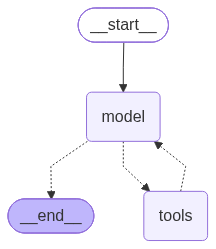

In [11]:
display(Image(agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [12]:
response = agent.invoke(
    {"messages": [HumanMessage("Qual é o meu cadastro?")]},
    context=ClinicContext(patient_id="123", unit="Centro"),
)
print(response["messages"][-1].content)

Seu cadastro é de Ana Souza, com convênio Alura Saúde.


In [13]:
response_unit = agent.invoke(
    {"messages": [HumanMessage("Com qual unidade da clínica estou falando?")]},
    context=ClinicContext(patient_id="123", unit="Centro"),
)
print(response_unit["messages"][-1].content)

Você está falando com a unidade Centro da Clínica Alura.


A mesma pergunta que um `create_agent` sem tools não conseguia responder (porque `system_prompt` é uma
string fixa) agora funciona: `get_current_unit` consulta `runtime.context.unit` direto, sem precisar
reescrever o prompt de sistema nem tocar no banco.

## Command: a única forma de uma tool atualizar estado

Uma tool não devolve um dicionário de atualização como um nó: o que ela retorna vira o conteúdo de um
`ToolMessage`, ponto final. Não existe um `return {"campo": valor}` para uma tool mudar outro campo do
estado. `Command` é o que resolve isso, e é a única forma de fazer: incluindo um `ToolMessage` amarrado ao
`tool_call_id` da chamada.

In [14]:
class ClinicAgentState(AgentState):
    verified: bool

In [15]:
@tool
def confirm_identity(runtime: ToolRuntime[ClinicContext]) -> Command:
    """Confirma a identidade da paciente atual a partir do contexto de runtime."""
    return Command(
        update={
            "verified": True,
            "messages": [
                ToolMessage(
                    content=f"Identidade confirmada para o paciente {runtime.context.patient_id}.",
                    tool_call_id=runtime.tool_call_id,
                )
            ],
        }
    )

In [16]:
agent_with_verification = create_agent(
    model=model,
    tools=[confirm_identity],
    state_schema=ClinicAgentState,
    system_prompt="Você é o assistente da Clínica Alura. Responda de forma cordial, curta e objetiva.",
    context_schema=ClinicContext,
)

In [17]:
response = agent_with_verification.invoke(
    {"messages": [HumanMessage("Pode confirmar minha identidade antes de eu continuar?")]},
    context=ClinicContext(patient_id="123", unit="Centro"),
)
print(response["verified"])
print(response["messages"][-1].content)

True
Sua identidade foi confirmada. Como posso ajudar você hoje?


In [18]:
response

{'messages': [HumanMessage(content='Pode confirmar minha identidade antes de eu continuar?', additional_kwargs={}, response_metadata={}, id='f2413764-2fdb-41d4-ad56-5caacdd1c70e'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 75, 'total_tokens': 85, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6339e52f56', 'id': 'chatcmpl-EFdzCn4FGDqLEL9WxXaHoQ1KnQ1O5', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0292e-e35b-73d1-8d32-435210e74481-0', tool_calls=[{'name': 'confirm_identity', 'args': {}, 'id': 'call_7Qpr5VxBTrkwKOovXY1wGGOE', 'type': 'tool_call'}], invalid_tool_calls=[], 

## Command também funciona num nó puro

Um nó comum decide o próximo passo com `add_edge`/`add_conditional_edges`, definidos fora dele. `Command`
também está disponível ali: um nó pode atualizar o estado e escolher para onde ir ao mesmo tempo,
devolvendo um `Command` em vez de um dicionário.

In [19]:
URGENCY_KEYWORDS = ["peito", "sangra", "desmai"]

In [20]:
class TriageState(MessagesState):
    triage: str

In [21]:
def triage(state: TriageState) -> Command[Literal["human_handoff", "answer"]]:
    message = state["messages"][-1].content.lower()
    if any(keyword in message for keyword in URGENCY_KEYWORDS):
        return Command(update={"triage": "urgente"}, goto="human_handoff")
    return Command(update={"triage": "normal"}, goto="answer")

In [22]:
def human_handoff(state: TriageState) -> dict:
    return {"messages": [AIMessage("Isso parece urgente. Encaminhando para atendimento humano.")]}

In [23]:
def answer_plain(state: TriageState) -> dict:
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [24]:
triage_builder = StateGraph(TriageState)
triage_builder.add_node("triage", triage)
triage_builder.add_node("human_handoff", human_handoff)
triage_builder.add_node("answer", answer_plain)
triage_builder.add_edge(START, "triage")
triage_builder.add_edge("human_handoff", END)
triage_builder.add_edge("answer", END)
triage_graph = triage_builder.compile()

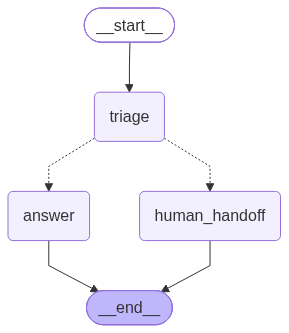

In [25]:
display(Image(triage_graph.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

Repare que não existe `add_conditional_edges` nesse grafo: o roteamento inteiro vem do `goto` dentro do
próprio `triage`.

In [26]:
urgent = triage_graph.invoke({"messages": [HumanMessage("Estou com uma dor forte no peito")]})
print(urgent["triage"], "→", urgent["messages"][-1].content)

urgente → Isso parece urgente. Encaminhando para atendimento humano.


In [27]:
urgent

{'messages': [HumanMessage(content='Estou com uma dor forte no peito', additional_kwargs={}, response_metadata={}, id='1b39f06a-52ca-4879-abc4-ec62954acf07'),
  AIMessage(content='Isso parece urgente. Encaminhando para atendimento humano.', additional_kwargs={}, response_metadata={}, id='4c26c60d-192c-4e51-9b2b-1fd19155d91c', tool_calls=[], invalid_tool_calls=[])],
 'triage': 'urgente'}

In [28]:
normal = triage_graph.invoke({"messages": [HumanMessage("Quero agendar uma consulta")]})
print(normal["triage"], "→", normal["messages"][-1].content)

normal → Claro! Para agendar uma consulta, você pode me informar alguns detalhes, como:

1. Tipo de consulta (médica, psicológica, etc.)
2. Especialidade (se aplicável)
3. Data e horário preferidos
4. Localização (se necessário)

Com essas informações, poderei te ajudar melhor!


In [29]:
normal

{'messages': [HumanMessage(content='Quero agendar uma consulta', additional_kwargs={}, response_metadata={}, id='3b61edb6-592d-43b9-9fdd-4a9bfe7fa2e8'),
  AIMessage(content='Claro! Para agendar uma consulta, você pode me informar alguns detalhes, como:\n\n1. Tipo de consulta (médica, psicológica, etc.)\n2. Especialidade (se aplicável)\n3. Data e horário preferidos\n4. Localização (se necessário)\n\nCom essas informações, poderei te ajudar melhor!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 13, 'total_tokens': 80, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_18fc98c6d2', 'id': 'chatcmpl-EFe1F1mhQb9qlBbwsBmAle4Idbc1g', 'service_tier': 'def

## Takeaway

`ToolRuntime` é o `Runtime` de sempre, agora dentro de uma tool. Para escrever, `Command` é o único
mecanismo: uma tool não tem outro jeito de tocar o estado além do `ToolMessage` que devolve. O mesmo
`Command` também funciona num nó puro, aí como conveniência: substitui `add_conditional_edges` quando um nó
já sabe, sozinho, para onde ir.